In [34]:
import sys; sys.path.insert(0, "/work/nvme/bbjs/sbharadwaj/powsm/xeuspr")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from src.metrics.phone_recognition import PhoneRecognitionEvaluator
from src.recipe.phone_recognition.local.error_analysis_utils import *

# Session-specific constants (not in utils)
MODEL = 'xeus_multiaccent.interctc_l4_8_12.bs256.lr3em5.sched_p05warm_p75const_3kunfreeze.100ksteps.ck22000'
K = 15; N_TOP = 20; FER_THRESHOLD = 50; N_DISPLAY = 10; PLOT_LANG = 'ady'
evaluator = PhoneRecognitionEvaluator(normalize_ipa=True)

In [35]:
# ── Reload utils ─────────────────────────────────────────────────────────────
# Run this cell after editing error_analysis_utils.py to pick up changes
# without restarting the kernel.
import importlib
import src.recipe.phone_recognition.local.error_analysis_utils as _eau
importlib.reload(_eau)
from src.recipe.phone_recognition.local.error_analysis_utils import *
print("error_analysis_utils reloaded.")

error_analysis_utils reloaded.


In [3]:
TRAIN_LANGS = load_train_langs(IPAPACK_YAML)

  Reading train: /work/hdd/bbjs/shared/powsm/s2t1/dump/raw/train_fixed/text
  Reading train_accentmix_multi: /work/nvme/bbjs/sbharadwaj/powsm/xeuspr/exp/data/train_fixed_all_partitions/text
  Reading train_accentmix_en: /work/nvme/bbjs/sbharadwaj/powsm/xeuspr/exp/data/train_fixed_all_partitions/text

Total training languages: 87


In [4]:
print("=== voxangeles ===")
voxangeles_preds = load_dataset_predictions("voxangeles", models=[MODEL])
print("\n=== doreco ===")
doreco_preds = load_dataset_predictions("doreco", models=[MODEL])
print("\n=== tusom ===")
tusom_preds = load_dataset_predictions("tusom", models=[MODEL])
print("\n=== buckeye ===")
buckeye_preds = load_dataset_predictions("buckeye", models=[MODEL])
print("\n=== gmuaccent ===")
gmuaccent_preds = load_dataset_predictions("gmuaccent", models=[MODEL])

=== voxangeles ===
  xeus_multiaccent.interctc_l4_8_12.bs256.lr3em5.sched_p05warm_p75const_3kunfreeze.100ksteps.ck22000: 5445 utts across 95 lang(s)

=== doreco ===
  xeus_multiaccent.interctc_l4_8_12.bs256.lr3em5.sched_p05warm_p75const_3kunfreeze.100ksteps.ck22000: 18734 utts across 45 lang(s)

=== tusom ===
  xeus_multiaccent.interctc_l4_8_12.bs256.lr3em5.sched_p05warm_p75const_3kunfreeze.100ksteps.ck22000: 2255 utts across 1 lang(s)

=== buckeye ===
  xeus_multiaccent.interctc_l4_8_12.bs256.lr3em5.sched_p05warm_p75const_3kunfreeze.100ksteps.ck22000: 10254 utts across 1 lang(s)

=== gmuaccent ===
  xeus_multiaccent.interctc_l4_8_12.bs256.lr3em5.sched_p05warm_p75const_3kunfreeze.100ksteps.ck22000: 1242 utts across 192 lang(s)


In [5]:
df_voxangeles = compute_metrics("voxangeles", voxangeles_preds)

va_audio = lambda u: audio_duration(u, VA_AUDIO_PATTERN)
df_utt = build_utt_dataframe(voxangeles_preds, evaluator, audio_fn=va_audio)
print(df_utt.shape)
print(f"Missing durations: {df_utt['duration'].isna().sum()}")
df_utt.head()

voxangeles models: 100%|██████████| 1/1 [00:01<00:00,  1.77s/it]


(5445, 11)
Missing durations: 0


,utt_id,langcode,langname,reference,predicted,pfer,fer,fed,per,n_phones,duration
0,lit-002-067-28,lit,Lithuanian,iːstʲɾʲɪʒʲaɪ,ɪstrʒɑjəjɪstrɪʒɑs,9.625000,110.156250,8.812500,175.000000,8,2.790062
1,lit-002-069-29,lit,Lithuanian,iispuːdʲɪs,is̪pud͡ʑis̪,1.333333,15.625000,1.250000,75.000000,8,1.320062
2,lit-002-070-30,lit,Lithuanian,dʲeːka,d̪ieka,1.125000,26.041667,1.041667,75.000000,4,1.200063
3,lit-002-111-31,lit,Lithuanian,tʊɾʲtʲɛ,t̪urt̪e,0.291667,5.416667,0.270833,100.000000,5,1.080000
4,lit-002-112-32,lit,Lithuanian,tʊɾtas,t̪ɔrt̪as̪,0.166667,2.777778,0.166667,83.333333,6,1.230000


In [6]:
df_utt.groupby("langcode")["fer"].mean().sort_values(ascending=False)

langcode
wuu    41.417254
col    41.228923
led    38.858696
cbv    37.115050
ady    29.202086
         ...    
deg     5.720730
cha     5.351769
eus     5.242402
bem     4.894053
fub     4.076087
Name: fer, Length: 95, dtype: float64

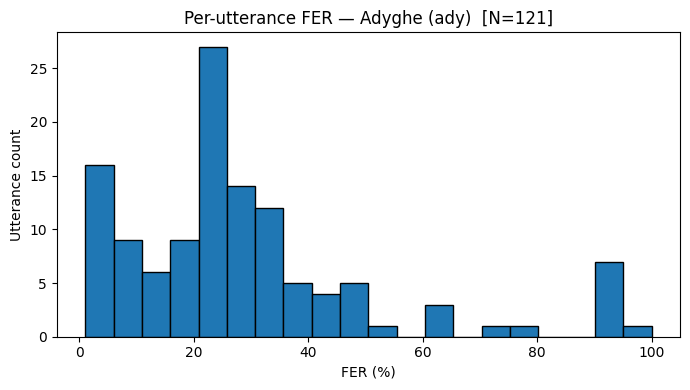

In [7]:
# Change PLOT_LANG in Cell 1 to plot a different language
lang_df = df_utt[df_utt["langcode"] == PLOT_LANG]
lname = lang_df["langname"].iloc[0] if len(lang_df) > 0 else PLOT_LANG

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(lang_df["fer"], bins=20, edgecolor="black")
ax.set_xlabel("FER (%)")
ax.set_ylabel("Utterance count")
ax.set_title(f"Per-utterance FER — {lname} ({PLOT_LANG})  [N={len(lang_df)}]")
plt.tight_layout()
plt.show()

In [8]:
# Tag utterances as in-domain / out-of-domain based on training languages
df_utt["domain"] = df_utt["langcode"].apply(
    lambda c: "in-domain" if c in TRAIN_LANGS else "out-of-domain"
)

# Per-language pooled FER (total_fed / total_phones approximated via mean here,
# but we use the utterance-level fer mean as a per-language summary)
lang_fer = (
    df_utt.groupby(["langcode", "langname", "domain"])["fer"]
    .agg(N="count", FER_mean="mean", FER_std="std")
    .reset_index()
    .sort_values("FER_mean", ascending=False)
)

# Summary: macro-average FER per domain
domain_summary = lang_fer.groupby("domain")["FER_mean"].agg(
    n_langs="count",
    macro_FER_mean="mean",
    macro_FER_std="std",
)
print("=== In-domain vs Out-of-domain (macro-avg over languages) ===")
print(domain_summary.to_string())

print(f"\nIn-domain languages in voxangeles:     {sorted(lang_fer[lang_fer['domain']=='in-domain']['langname'].tolist())}")
print(f"\nOut-of-domain languages in voxangeles: {sorted(lang_fer[lang_fer['domain']=='out-of-domain']['langname'].tolist())}")
print('Overall FER', lang_fer["FER_mean"].mean())

=== In-domain vs Out-of-domain (macro-avg over languages) ===
               n_langs  macro_FER_mean  macro_FER_std
domain                                               
in-domain           18       13.018229       5.069411
out-of-domain       77       15.854082       7.909244

In-domain languages in voxangeles:     ['Afrikaans', 'Basque', 'Bengali', 'Burmese', 'Croatian', 'Czech', 'Danish', 'Dutch', 'Finnish', 'Hausa', 'Hindi', 'Hungarian', 'Icelandic', 'Lithuanian', 'Malayalam', 'Maltese', 'Modern Greek (1453-)', 'Yue Chinese']

Out-of-domain languages in voxangeles: ['Abkhazian', 'Achinese', 'Adamawa Fulfulde', 'Adyghe', 'Aghul', 'Akan', 'Angami Naga', 'Armenian', 'Assamese', 'Badaga', 'Bafut', 'Bambara', 'Bassa', 'Bemba (Zambia)', 'Bini', 'Bukiyip', 'Bura-Pabir', 'Cacua', 'Central Atlas Tamazight', 'Chamalal', 'Chamorro', 'Cherepon', 'Columbia-Wenatchi', 'Dagbani', 'Dari', 'Defaka', 'Degema', 'Efik', 'Emai-Iuleha-Ora', 'Ewe', 'Ga', 'Ganda', 'Gua', 'Gujarati', 'Hakka Chinese', 'Hani

In [9]:
def display_audio_for_utterance(utt_id: str):
    langcode = utt_id.split("-")[0]
    audio_path = VA_AUDIO_PATTERN.format(langcode=langcode, utt_id=utt_id)
    display(Audio(audio_path))

mask = (df_utt.fer > 60) & (df_utt.fer < 70)
for u in df_utt[mask]["utt_id"][:10]:
    langcode = u.split("-")[0]
    print(f"Utterance {u} (lang: {langcode}, FER: {df_utt[df_utt.utt_id==u]['fer'].iloc[0]:.1f}%)")
    print(f"  Reference: {df_utt[df_utt.utt_id==u]['reference'].iloc[0]}")
    print(f"  Predicted: {df_utt[df_utt.utt_id==u]['predicted'].iloc[0]}")
    print(f'  Duration: {df_utt[df_utt.utt_id==u]["duration"].iloc[0]:.1f} sec')
    display_audio_for_utterance(u)

Utterance mlt-000-121-54 (lang: mlt, FER: 61.1%)
  Reference: bahː
  Predicted: b
  Duration: 1.2 sec


Utterance mya-001-076-28 (lang: mya, FER: 66.0%)
  Reference: tʃʰa
  Predicted: tɕjɑŋ
  Duration: 0.9 sec


Utterance mya-001-086-38 (lang: mya, FER: 62.5%)
  Reference: ɲ̥ãŋ
  Predicted: a
  Duration: 0.8 sec


Utterance mya-001-087-53 (lang: mya, FER: 61.1%)
  Reference: tʊ̃ŋ
  Predicted: t
  Duration: 0.9 sec


Utterance mya-001-088-66 (lang: mya, FER: 62.5%)
  Reference: tʊ̃ŋ
  Predicted: ʈ
  Duration: 0.7 sec


Utterance mya-001-114-79 (lang: mya, FER: 62.5%)
  Reference: twɪ
  Predicted: tʰ
  Duration: 0.8 sec


Utterance mya-001-061-100 (lang: mya, FER: 62.5%)
  Reference: ẽɪ̃ŋ
  Predicted: e
  Duration: 0.9 sec


Utterance ozm-000-008-7 (lang: ozm, FER: 69.3%)
  Reference: nkøø
  Predicted: k
  Duration: 1.1 sec


Utterance pes-001-046-82 (lang: pes, FER: 69.8%)
  Reference: owdʒ
  Predicted: o
  Duration: 1.0 sec


Utterance pes-001-096-108 (lang: pes, FER: 68.1%)
  Reference: nan
  Predicted: n̪ɔn̪ma
  Duration: 1.0 sec


In [10]:
utt_id=df_utt[df_utt.fer>80]

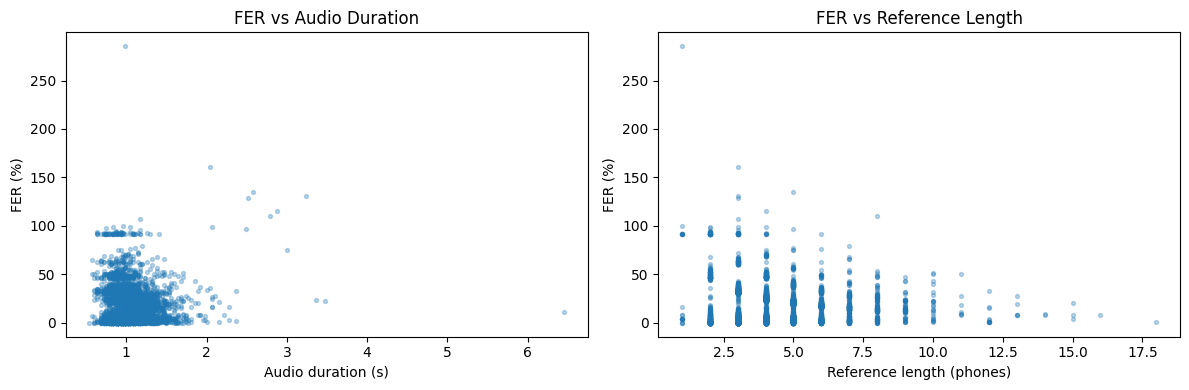

Corr(FER, duration):  0.000
Corr(FER, n_phones):  -0.046


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_df = df_utt.dropna(subset=["duration"])

# FER vs audio duration
axes[0].scatter(plot_df["duration"], plot_df["fer"], alpha=0.3, s=8)
axes[0].set_xlabel("Audio duration (s)")
axes[0].set_ylabel("FER (%)")
axes[0].set_title("FER vs Audio Duration")

# FER vs reference length (phones)
axes[1].scatter(plot_df["n_phones"], plot_df["fer"], alpha=0.3, s=8)
axes[1].set_xlabel("Reference length (phones)")
axes[1].set_ylabel("FER (%)")
axes[1].set_title("FER vs Reference Length")

plt.tight_layout()
plt.show()

# Pearson correlations
print(f"Corr(FER, duration):  {plot_df['fer'].corr(plot_df['duration']):.3f}")
print(f"Corr(FER, n_phones):  {plot_df['fer'].corr(plot_df['n_phones']):.3f}")

In [12]:
tus_audio = lambda u: audio_duration(u, TUSOM_AUDIO_PATTERN)
df_utt_tusom = build_utt_dataframe(tusom_preds, evaluator, audio_fn=tus_audio)
print(df_utt_tusom.shape)
print(f"Missing durations: {df_utt_tusom['duration'].isna().sum()}")
print(f"\nOverall FER: {df_utt_tusom['fer'].mean():.2f}%")
df_utt_tusom.sort_values("fer", ascending=False).head()

(2255, 11)
Missing durations: 0

Overall FER: 22.82%


,utt_id,langcode,langname,reference,predicted,pfer,fer,fed,per,n_phones,duration
1984,verb17-19,unk,Enawené-Nawé,ɑ,ket͡ʃuo,4.125000,379.166667,3.791667,500.0,1,1.614739
915,pronouns1-27,unk,Enawené-Nawé,ninã,jutusakarninena,11.041667,253.645833,10.145833,300.0,4,2.227392
1504,bp11-37,unk,Enawené-Nawé,ʔibie,oʊ̃nliðətʰiŋɪzibie,11.208333,207.916667,10.395833,240.0,5,1.475918
647,people1-117,unk,Enawené-Nawé,kər̥i,ekesitetaŋɡ̤u,8.291667,190.104167,7.604167,250.0,4,3.365306
879,plants1-70,unk,Enawené-Nawé,zɯə,kuklazɯa̯,5.125000,157.638889,4.729167,200.0,3,1.380181


In [13]:
# Display poor performing tusom utterances — change threshold or N as needed
FER_THRESHOLD = 50
N_DISPLAY = 10

poor = df_utt_tusom[df_utt_tusom["fer"] >= FER_THRESHOLD].sort_values("fer", ascending=False)
print(f"{len(poor)} utterances with FER >= {FER_THRESHOLD}% — showing top {N_DISPLAY}\n")

for _, row in poor.head(N_DISPLAY).iterrows():
    print(f"utt_id:    {row['utt_id']}")
    print(f"FER:       {row['fer']:.1f}%  |  PER: {row['per']:.1f}%  |  duration: {row['duration']:.2f}s  |  n_phones: {row['n_phones']}")
    print(f"reference: {row['reference']}")
    print(f"predicted: {row['predicted']}")
    display(Audio(TUSOM_AUDIO_PATTERN.format(utt_id=row['utt_id'])))
    print()

154 utterances with FER >= 50% — showing top 10

utt_id:    verb17-19
FER:       379.2%  |  PER: 500.0%  |  duration: 1.61s  |  n_phones: 1
reference: ɑ
predicted: ket͡ʃuo



utt_id:    pronouns1-27
FER:       253.6%  |  PER: 300.0%  |  duration: 2.23s  |  n_phones: 4
reference: ninã
predicted: jutusakarninena



utt_id:    bp11-37
FER:       207.9%  |  PER: 240.0%  |  duration: 1.48s  |  n_phones: 5
reference: ʔibie
predicted: oʊ̃nliðətʰiŋɪzibie



utt_id:    people1-117
FER:       190.1%  |  PER: 250.0%  |  duration: 3.37s  |  n_phones: 4
reference: kər̥i
predicted: ekesitetaŋɡ̤u



utt_id:    plants1-70
FER:       157.6%  |  PER: 200.0%  |  duration: 1.38s  |  n_phones: 3
reference: zɯə
predicted: kuklazɯa̯



utt_id:    bp4-79
FER:       132.5%  |  PER: 200.0%  |  duration: 4.45s  |  n_phones: 5
reference: kʰanny
predicted: kɑnɯkɑnɯkɑnɯ



utt_id:    verb7-10
FER:       113.8%  |  PER: 180.0%  |  duration: 1.63s  |  n_phones: 5
reference: kətʰuə
predicted: t͡ɕudrapkɤtʰwɔ



utt_id:    verb12-37
FER:       95.5%  |  PER: 128.6%  |  duration: 2.94s  |  n_phones: 7
reference: vankədi
predicted: hodasaavaŋɡədi



utt_id:    pronouns1-44
FER:       92.7%  |  PER: 100.0%  |  duration: 1.16s  |  n_phones: 4
reference: nina
predicted: 



utt_id:    pronouns1-9
FER:       92.7%  |  PER: 100.0%  |  duration: 0.48s  |  n_phones: 2
reference: nã
predicted: 


In [14]:
empty_pred_mask = df_utt_tusom["predicted"].str.strip() == ""

print(f"Utterances with empty prediction: {empty_pred_mask.sum()} / {len(df_utt_tusom)}")
print()
df_utt_tusom[empty_pred_mask].sort_values("fer", ascending=False).head(10)
for u in df_utt_tusom[empty_pred_mask]["utt_id"]:
    print(f"Utterance {u} (FER: {df_utt_tusom[df_utt_tusom.utt_id==u]['fer'].iloc[0]:.1f}%)")
    print(f"  Reference: {df_utt_tusom[df_utt_tusom.utt_id==u]['reference'].iloc[0]}")
    print(f"  Predicted: {df_utt_tusom[df_utt_tusom.utt_id==u]['predicted'].iloc[0]}")
    print(f'  Duration: {df_utt_tusom[df_utt_tusom.utt_id==u]["duration"].iloc[0]:.1f} sec')
    display(Audio(TUSOM_AUDIO_PATTERN.format(utt_id=u)))

Utterances with empty prediction: 12 / 2255

Utterance bp9-85 (FER: 92.3%)
  Reference: kəzɯtχa
  Predicted: 
  Duration: 0.2 sec


Utterance implements-131 (FER: 92.4%)
  Reference: ɹɯe
  Predicted: 
  Duration: 1.2 sec


Utterance people3-102 (FER: 91.7%)
  Reference: ʔɯmɯ̃ə
  Predicted: 
  Duration: 0.9 sec


Utterance people3-11 (FER: 92.0%)
  Reference: ʔəŋənu
  Predicted: 
  Duration: 0.6 sec


Utterance plants1-18 (FER: 92.2%)
  Reference: ʔit͡ɕʰi
  Predicted: 
  Duration: 1.2 sec


...

Utterance pronouns1-44 (FER: 92.7%)
  Reference: nina
  Predicted: 
  Duration: 1.2 sec


Utterance pronouns1-9 (FER: 92.7%)
  Reference: nã
  Predicted: 
  Duration: 0.5 sec


Utterance verb12-29 (FER: 91.8%)
  Reference: ŋəli kəpr̥i kʰəkəpãnlo
  Predicted: 
  Duration: 1.7 sec


Utterance animals2-69 (FER: 92.1%)
  Reference: ʔɯɹ̥ɯə
  Predicted: 
  Duration: 1.0 sec


Utterance verb14-96 (FER: 91.7%)
  Reference: ʔəxɯe
  Predicted: 
  Duration: 1.1 sec


In [15]:
# Phone confusion matrix on TUSOM (DEL_SYM / INS_SYM are defined in utils)
df_confusion_tusom = phone_confusion_matrix(df_utt_tusom, evaluator)
print(f"Total unique (ref, hyp) pairs: {len(df_confusion_tusom)}\n")
print(f"Top {N_TOP} confusion pairs:")
df_confusion_tusom.head(N_TOP)

Total unique (ref, hyp) pairs: 910

Top 20 confusion pairs:


,ref,hyp,count
0,ʔ,<DEL>,762
1,ə,a,468
2,ə,<DEL>,403
3,ɯ,<DEL>,290
4,ə,e,247
5,ə,ɤ,164
6,ɯ,u,138
7,u,<DEL>,136
8,i,<DEL>,135
9,k,<DEL>,131


In [16]:
df_utt_buckeye = build_utt_dataframe(buckeye_preds, evaluator)
print(df_utt_buckeye.shape)
print(f"Overall FER: {df_utt_buckeye['fer'].mean():.2f}%")
df_utt_buckeye.head()

# Phone confusion matrix on buckeye
df_confusion_buckeye = phone_confusion_matrix(df_utt_buckeye, evaluator)
print(f"\nTotal unique (ref, hyp) pairs: {len(df_confusion_buckeye)}\n")
print(f"Top {N_TOP} confusion pairs:")
df_confusion_buckeye.head(N_TOP)

(10254, 11)
Overall FER: 12.74%

Total unique (ref, hyp) pairs: 1918

Top 20 confusion pairs:


,ref,hyp,count
0,ʌ,ə,7730
1,ɪ,ɪ̃,5927
2,<INS>,ə,3995
3,ɪ,ə,3794
4,b,p,3776
5,d,t,3765
6,<INS>,t,3433
7,t,tʰ,3414
8,ʔ,t,3256
9,k,kʰ,3062


In [17]:
df_utt_gmuaccent = build_utt_dataframe(gmuaccent_preds, evaluator)
print(df_utt_gmuaccent.shape)
print(f"Overall PFER: {df_utt_gmuaccent['pfer'].mean():.2f}%")

# PFER per accent — sorted by utterance count (descending), top 10
accent_pfer = (
    df_utt_gmuaccent.groupby(["langcode", "langname"])
    .agg(n_utts=("pfer", "count"), pfer_mean=("pfer", "mean"), pfer_std=("pfer", "std"))
    .reset_index()
    .sort_values("n_utts", ascending=False)
    .head(10)
    .rename(columns={"langcode": "accent", "langname": "accent_name",
                     "n_utts": "N", "pfer_mean": "PFER", "pfer_std": "PFER_std"})
)
print(f"\nTop 10 accents by utterance count:")
accent_pfer.style.format({"PFER": "{:.2f}", "PFER_std": "{:.2f}"})

(1242, 11)
Overall PFER: 20.88%

Top 10 accents by utterance count:


,accent,accent_name,N,PFER,PFER_std
38,english,english,185,18.39,4.94
155,spanish,spanish,72,23.63,6.48
5,arabic,arabic,62,22.24,6.88
49,french,french,43,19.22,3.83
35,dutch,dutch,42,16.97,3.59
132,portuguese,portuguese,39,22.02,5.36
139,russian,russian,31,21.09,7.97
56,german,german,28,17.09,4.27
104,mandarin,mandarin,28,22.33,4.83
72,italian,italian,27,20.55,5.19


In [30]:
accent_pfer = (
    df_utt_gmuaccent.groupby(["langcode", "langname"])
    .agg(n_utts=("pfer", "count"), pfer_mean=("pfer", "mean"), pfer_std=("pfer", "std"))
    .reset_index()
    .sort_values("n_utts", ascending=False)
    .rename(columns={"langcode": "accent", "langname": "accent_name",
                     "n_utts": "N", "pfer_mean": "PFER", "pfer_std": "PFER_std"})
)
accent_pfer = accent_pfer[accent_pfer["N"] >= 10]  # Filter accents with at least 20 utterances

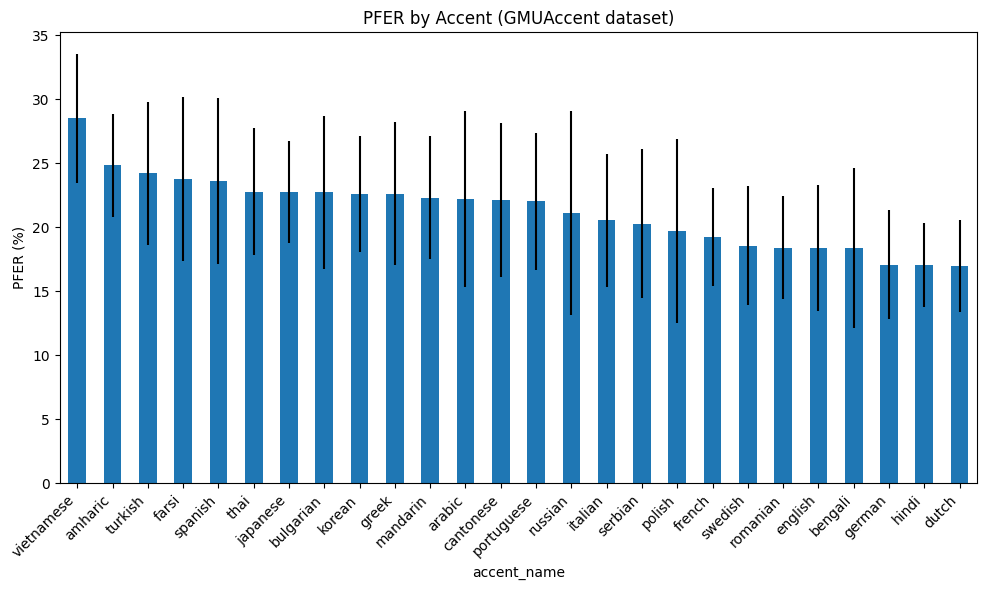

In [31]:
accent_pfer = accent_pfer.sort_values("PFER", ascending=False)
accent_pfer.plot(x="accent_name", y="PFER", kind="bar", yerr="PFER_std", legend=False, figsize=(10, 6))
plt.ylabel("PFER (%)")
plt.title("PFER by Accent (GMUAccent dataset)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [38]:
# Jaccard similarity: reference vs predicted phone inventory (per utterance, aggregated per language)
df_jaccard = phone_inventory_jaccard(df_utt_gmuaccent, evaluator)

print(f"Mean Jaccard (all utterances): {df_jaccard['jaccard'].mean():.3f}")
print(f"Median Jaccard:                {df_jaccard['jaccard'].median():.3f}\n")

# Per-language summary — sorted by mean Jaccard ascending (worst first)
lang_jaccard = (
    df_jaccard.groupby(["langcode", "langname"])["jaccard"]
    .agg(N="count", mean="mean", median="median", std="std")
    .reset_index()
    .sort_values("mean")
)
print(f"Per-language Jaccard (worst {N_TOP}):")
lang_jaccard[lang_jaccard.N>10].head(N_TOP).style.format({"mean": "{:.3f}", "median": "{:.3f}", "std": "{:.3f}"})

Mean Jaccard (all utterances): 0.663
Median Jaccard:                0.667

Per-language Jaccard (worst 20):


,langcode,langname,N,mean,median,std
182,vietnamese,vietnamese,11,0.573,0.545,0.104
4,amharic,amharic,15,0.622,0.621,0.066
74,japanese,japanese,15,0.635,0.621,0.072
139,russian,russian,31,0.636,0.632,0.066
20,bulgarian,bulgarian,12,0.637,0.640,0.050
155,spanish,spanish,72,0.648,0.642,0.067
87,korean,korean,26,0.650,0.655,0.062
104,mandarin,mandarin,28,0.650,0.661,0.054
57,greek,greek,11,0.651,0.635,0.059
5,arabic,arabic,62,0.652,0.654,0.088
